In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
url = r'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'

df = pd.read_csv(url)
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Verificando relação entre gorjetas por quantidade de pessoas.


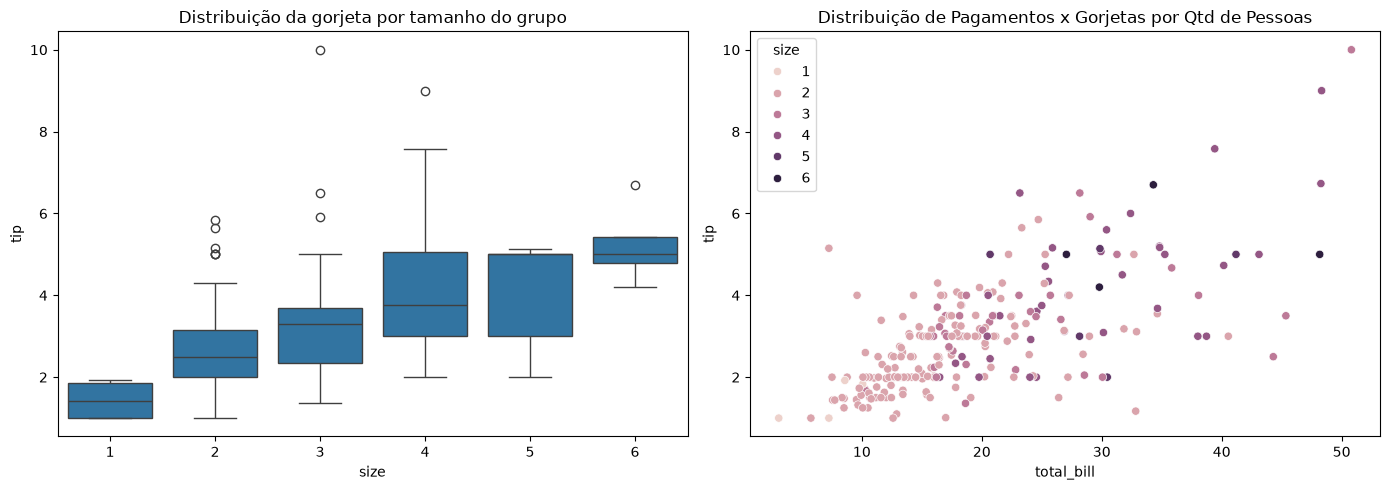

'mediana gorjeta de grupos com uma pessoa:'

np.float64(1.415)

'MEdiana de grupos com quatro pessoas:'

np.float64(3.76)

'Média dos grupos com 1uatro pessoas:'

np.float64(4.135405405405405)

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14,5))

gorjetas_pessoas = sns.boxplot(data=df, y='tip', x='size', ax=axes[0])
axes[0].set_title('Distribuição da gorjeta por tamanho do grupo')

contagem_pgmt_total_pessoas = sns.scatterplot(data=df, x='total_bill', y='tip', hue='size', ax=axes[1])
axes[1].set_title('Distribuição de Pagamentos x Gorjetas por Qtd de Pessoas')

plt.tight_layout()
plt.show()


mediana_size1 = df.loc[df['size'] == 1, 'tip'].median()
display('mediana gorjeta de grupos com uma pessoa:', mediana_size1)
mediana_size4 = df.loc[df['size'] == 4, 'tip'].median()
display('MEdiana de grupos com quatro pessoas:', mediana_size4)
media_size4 = df.loc[df['size'] == 4, 'tip'].mean()
display('Média dos grupos com 1uatro pessoas:', media_size4)

- Ao analisar a distribuição da gorjeta por tamanho do grupo, observamos que os outliers não estão distribuidos igualmente entre os grupos, ele se concentram principalmente nos grupos de tamanhos 2, 3, 4 e 6, enquanto o grupo de tamanho 1 não apresenta nenhum outlier visível.

- Também percebemos que conforme o tamanho do grupo aumenta, maior a mediana é, mas não necessariamente os outliers aumentam junto...

- Temos uma mediana bem baixa no grupo 1, de ~$1.4 de gorjeta, o que sugere que quando se está sozinho a gorjeta é bem mais previsivel.

- Também podemos reparar que a caixa representante aos grupos de 4 pessoas é mais larga, a distância entre primeiro e o terceiro quartil dela é o maior entre as caixas, talvez isso tudo indique que em grupos de quatro pessoas a gorjeta varie mais.

- Temos também a percepção de que o maior outlier está nos grupos de 3 pessoas, e também a variação de gorjeta ser maior nele do que nos grupos de 6 pessoas (o que seria mais intuitivo, já que grupos maiores teoricamente gastariam mais e suas gosrjetas concequentemente seriam maiores).

## Comparação entre almoço e jantar.

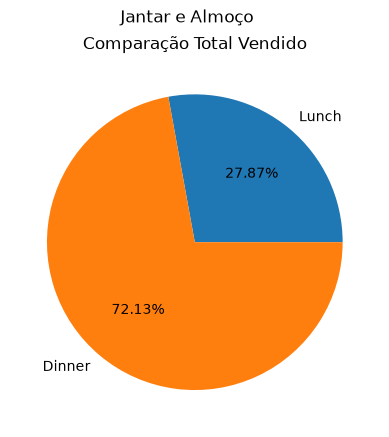

In [ ]:

launch_x_dinner = df.groupby(df['time'] == 'Dinner').count()

plt.pie(
        data=launch_x_dinner, 
        x=launch_x_dinner['total_bill'],
        labels=['Lunch', 'Dinner'],
        autopct='%1.2f%%'
)
plt.title('Comparação Total Vendido')
plt.suptitle('Jantar e Almoço')
plt.show()

### Distribuição das variáveis numéricas

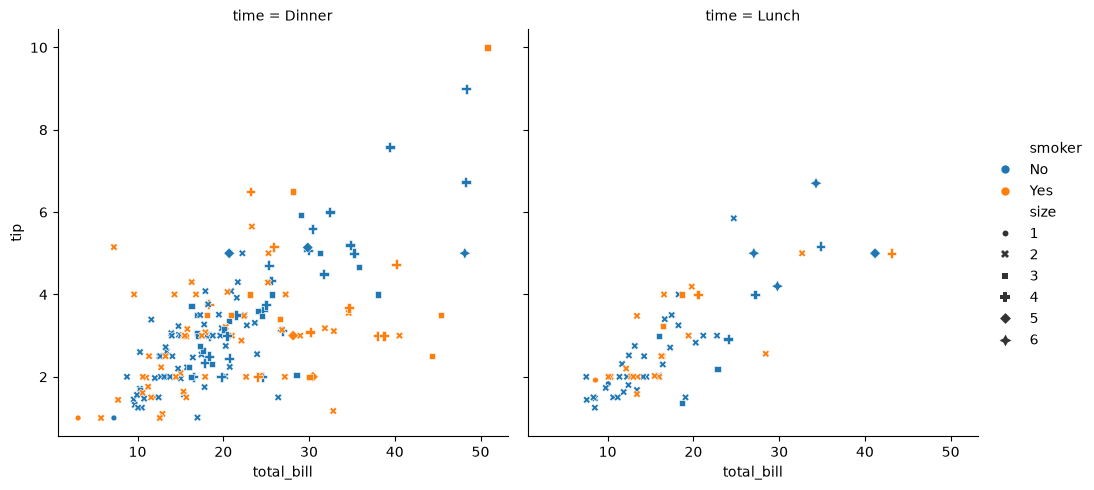

In [ ]:
sns.relplot(
    data=df,
    x="total_bill", y="tip", col="time",
    hue="smoker", style="size", size="size",
)

## Verificando distribuição entre as variáveis categóricas

In [9]:
for coluna in ['sex', 'smoker', 'day', 'time']:
    print(f'--- {coluna} ---')
    print(df[coluna].value_counts(),'\n')



--- sex ---
sex
Male      157
Female     87
Name: count, dtype: int64 

--- smoker ---
smoker
No     151
Yes     93
Name: count, dtype: int64 

--- day ---
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64 

--- time ---
time
Dinner    176
Lunch      68
Name: count, dtype: int64 



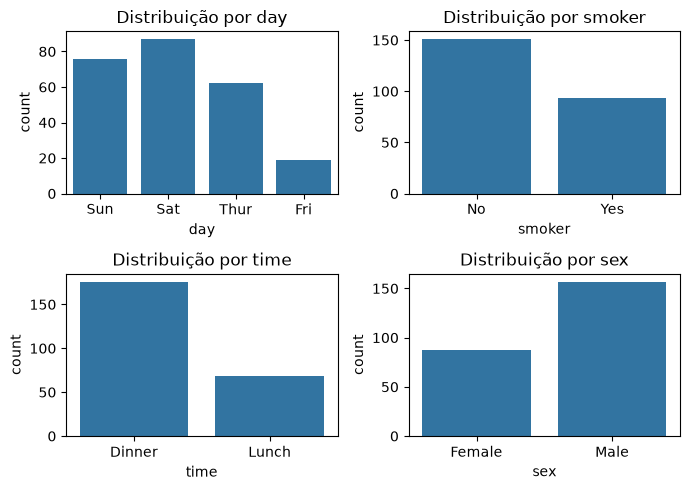

In [10]:
# Vizualizando a distribuição acima
fig, axes = plt.subplots(2, 2, figsize=(7,5))

for ax, col in zip(axes.flatten(), ['day', 'smoker', 'time', 'sex']):
    sns.countplot(df, x=col, ax=ax)
    ax.set_title(f'Distribuição por {col}')
    plt.tight_layout() # Espaçamento do layout!!!
